## Ai Ford Car Price Prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## EDA


In [2]:
df=pd.read_csv("ford.csv")
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [3]:
df.shape
df.size
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [4]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


<Axes: xlabel='year', ylabel='price'>

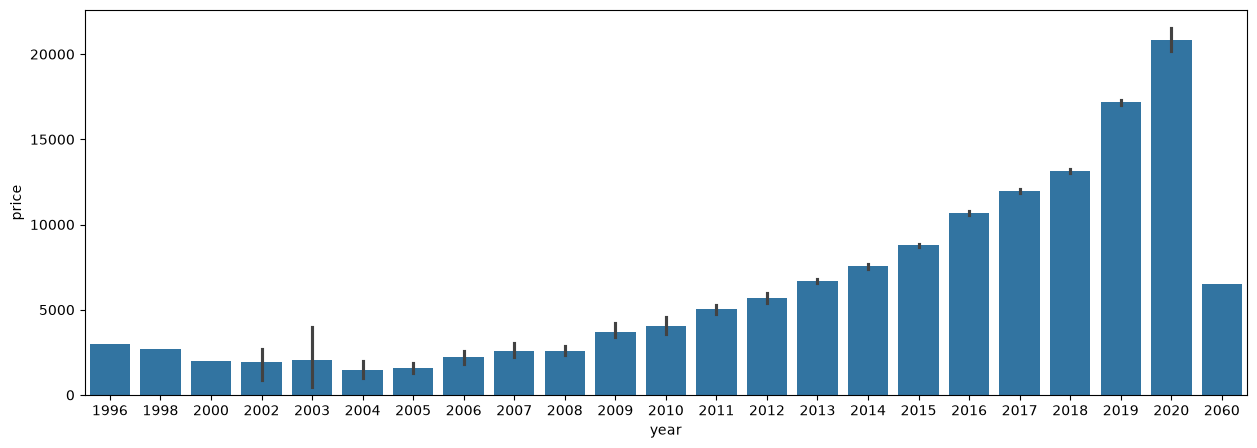

In [5]:
plt.figure(figsize=(15,5))
sns.barplot(x="year",y="price",data=df)

<Axes: xlabel='year', ylabel='price'>

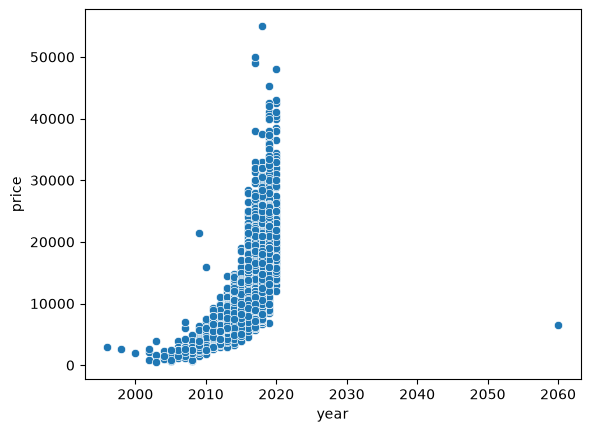

In [6]:
sns.scatterplot(x="year",y="price",data=df)

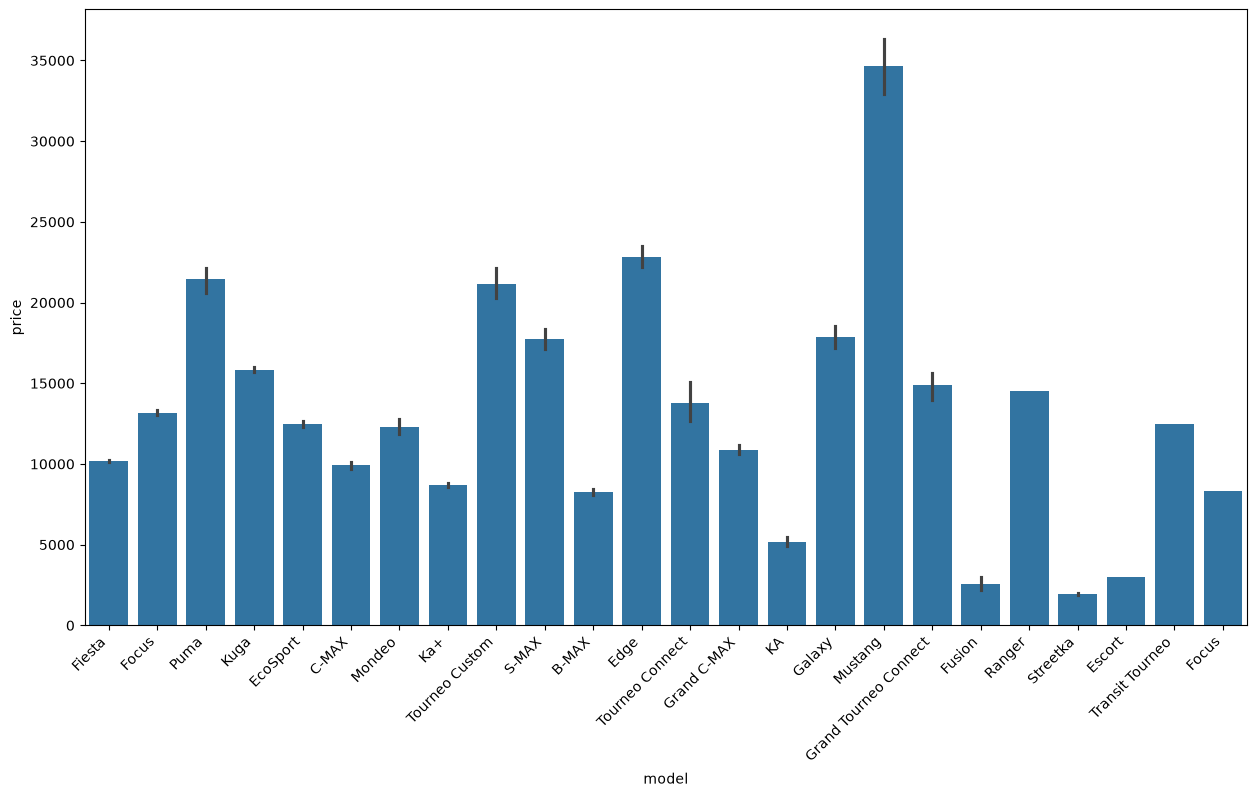

In [7]:
plt.figure(figsize=(15,8))
fig=sns.barplot(x="model",y="price",data=df)
plt.xticks(rotation=45, horizontalalignment='right') 
plt.show()

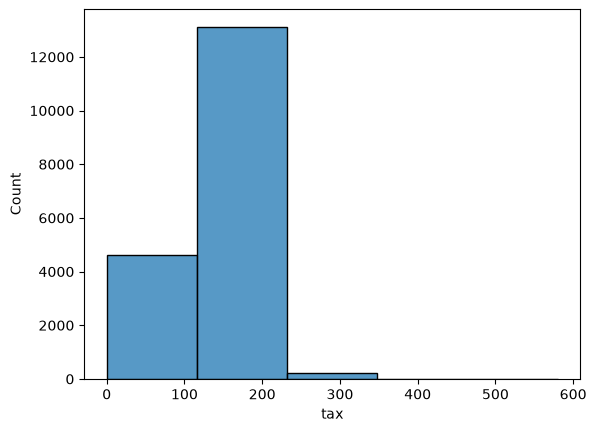

In [8]:
sns.histplot(x="tax",data=df,bins=5)
plt.show()

<Axes: xlabel='fuelType', ylabel='price'>

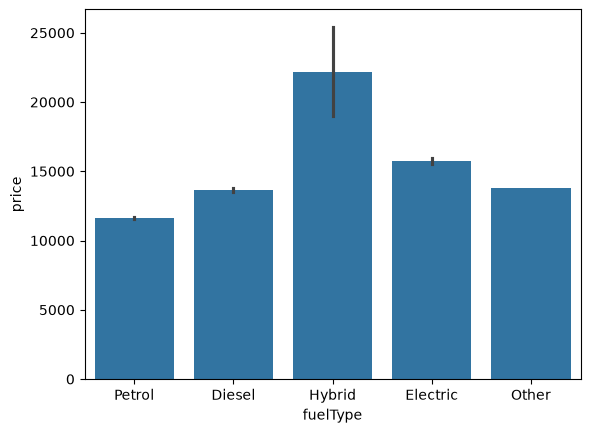

In [9]:
sns.barplot(x="fuelType",y="price",data=df)

<Axes: xlabel='fuelType', ylabel='price'>

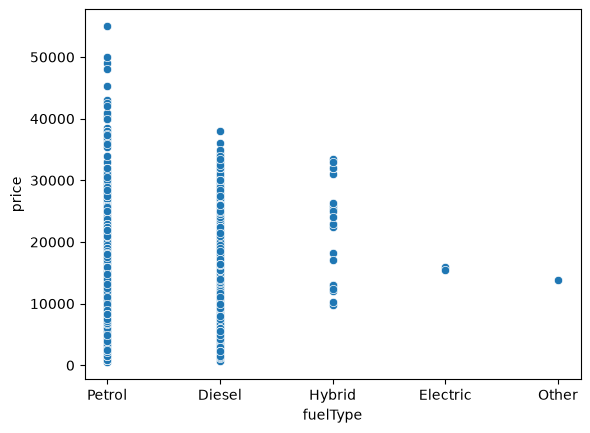

In [10]:
sns.scatterplot(x="fuelType",y="price",data=df)

<Axes: >

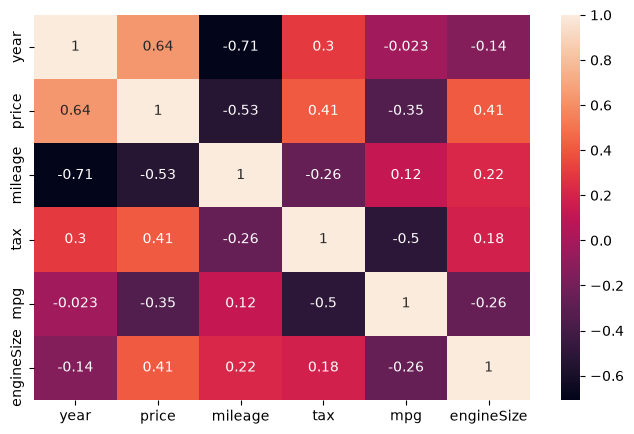

In [11]:
plt.figure(figsize=(8,5))
cor=df.corr(numeric_only=True)
sns.heatmap(cor,annot=True)

In [12]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='str')

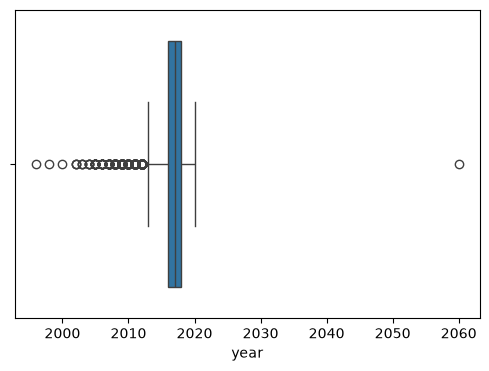

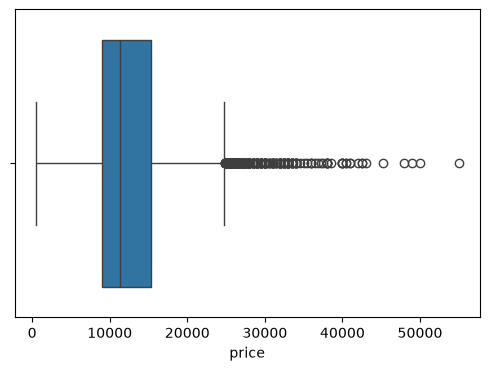

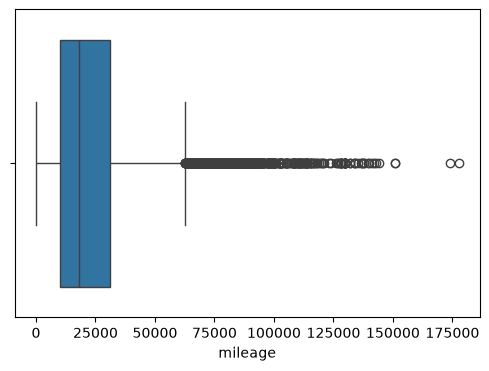

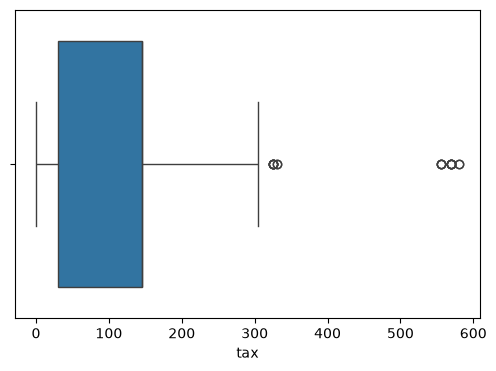

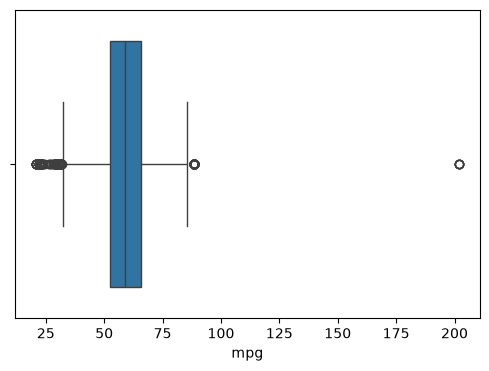

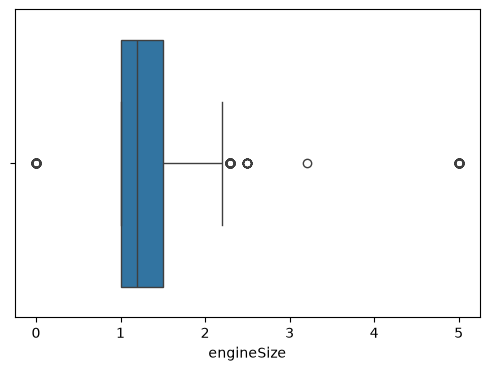

In [13]:
numeric_columns = ['year', 'price', 'mileage','tax',
       'mpg', 'engineSize' ]
for col in numeric_columns:
    plt.figure(figsize= (6,4))
    sns.boxplot(x = df[col])

<Axes: xlabel='mileage', ylabel='price'>

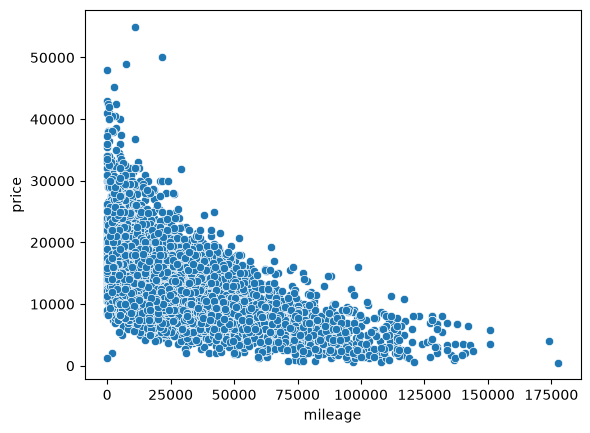

In [14]:
sns.scatterplot(x="mileage",y="price",data=df)

## Data Processing and Feature Extraction

In [15]:
df_clean = df.copy()

df_clean = pd.get_dummies(
    df_clean,
    columns=["fuelType"],
    drop_first=True
)

df_clean.head()

,model,year,price,transmission,mileage,tax,mpg,engineSize,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,Fiesta,2017,12000,Automatic,15944,150,57.7,1.0,False,False,False,True
1,Focus,2018,14000,Manual,9083,150,57.7,1.0,False,False,False,True
2,Focus,2017,13000,Manual,12456,150,57.7,1.0,False,False,False,True
3,Fiesta,2019,17500,Manual,10460,145,40.3,1.5,False,False,False,True
4,Fiesta,2019,16500,Automatic,1482,145,48.7,1.0,False,False,False,True


In [16]:
df_clean = pd.get_dummies(
    df_clean,
    columns=["model"],
    drop_first=True
)

df_clean.head()

,year,price,transmission,mileage,tax,mpg,engineSize,fuelType_Electric,fuelType_Hybrid,fuelType_Other,...,model_ Mondeo,model_ Mustang,model_ Puma,model_ Ranger,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus
0,2017,12000,Automatic,15944,150,57.7,1.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2018,14000,Manual,9083,150,57.7,1.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2017,13000,Manual,12456,150,57.7,1.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2019,17500,Manual,10460,145,40.3,1.5,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2019,16500,Automatic,1482,145,48.7,1.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [17]:
df_clean = pd.get_dummies(
    df_clean,
    columns=["transmission"],
    drop_first=True
)

df_clean.head()

,year,price,mileage,tax,mpg,engineSize,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,...,model_ Puma,model_ Ranger,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto
0,2017,12000,15944,150,57.7,1.0,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,2018,14000,9083,150,57.7,1.0,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
2,2017,13000,12456,150,57.7,1.0,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
3,2019,17500,10460,145,40.3,1.5,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
4,2019,16500,1482,145,48.7,1.0,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [18]:
df_clean=df_clean.astype(int)
df_clean

,year,price,mileage,tax,mpg,engineSize,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,...,model_ Puma,model_ Ranger,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto
0,2017,12000,15944,150,57,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,2018,14000,9083,150,57,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,2017,13000,12456,150,57,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
3,2019,17500,10460,145,40,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
4,2019,16500,1482,145,48,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,8999,16700,150,47,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
17962,2014,7499,40700,30,57,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
17963,2015,9999,7010,20,67,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
17964,2018,8299,5007,145,57,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0


<Axes: >

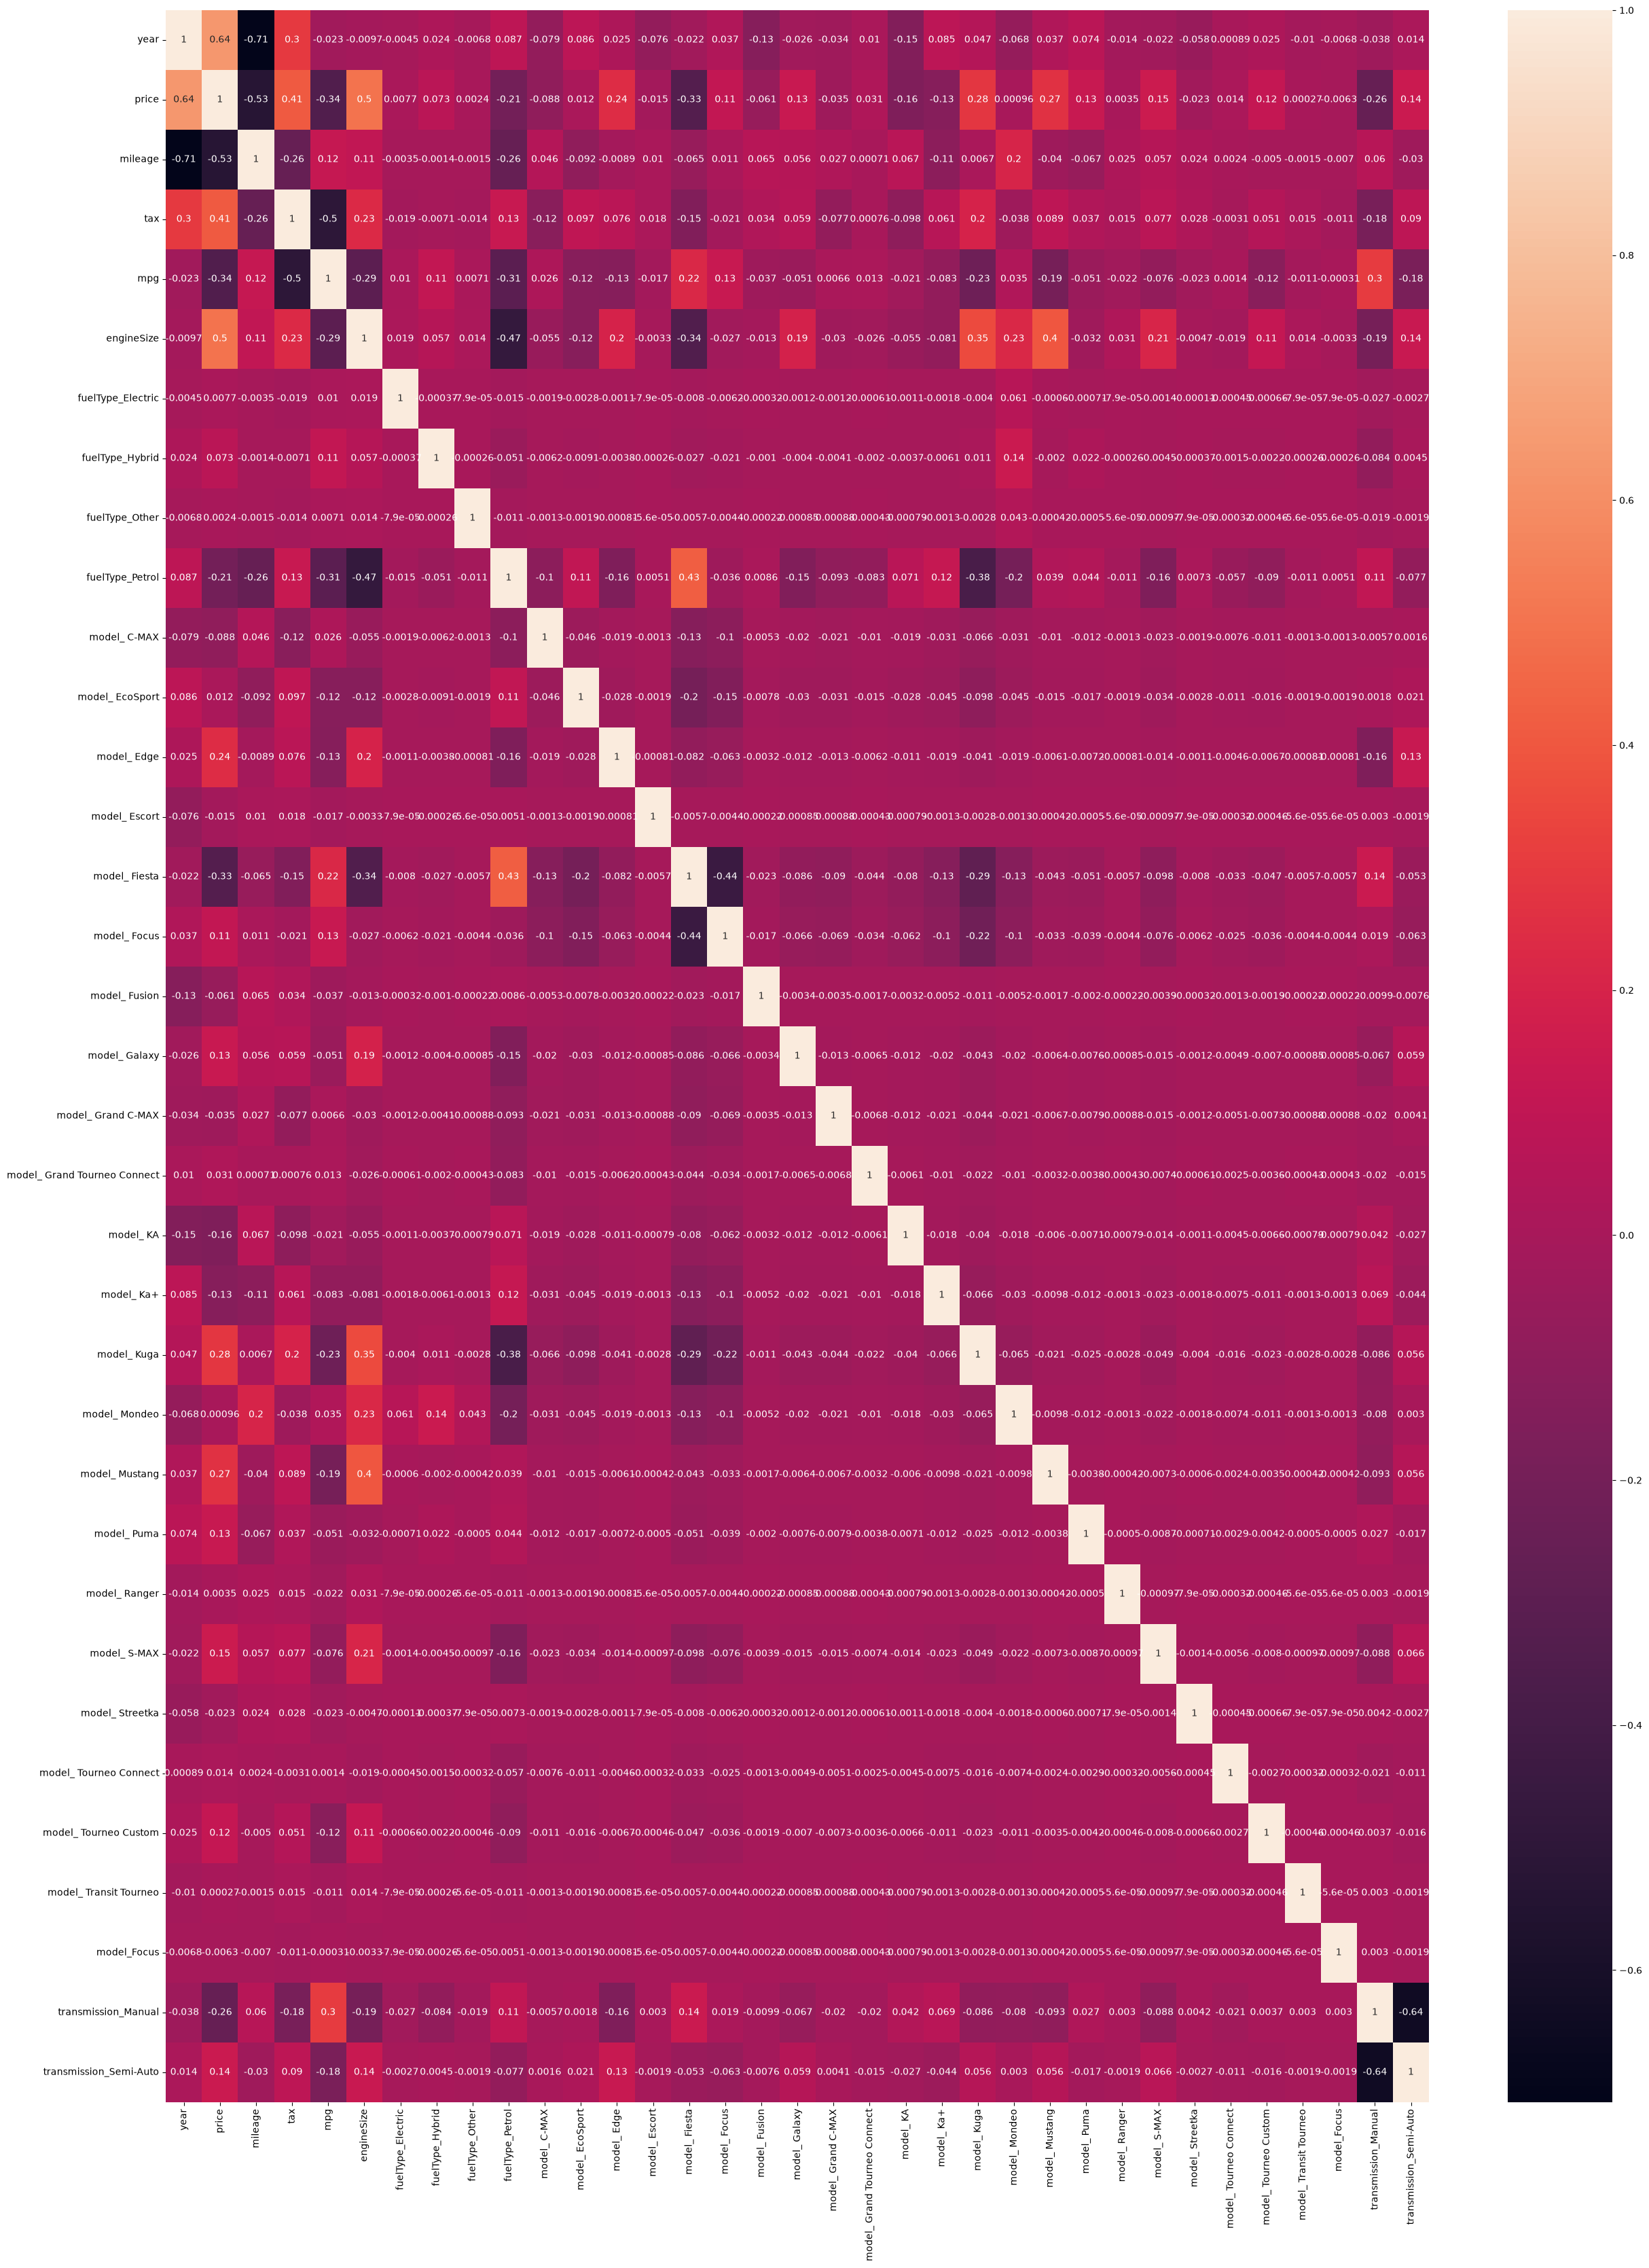

In [19]:
plt.figure(figsize=(30,40))
cor=df_clean.corr(numeric_only=True)
sns.heatmap(cor,annot=True)

## Train Data In Model

In [20]:
from sklearn.preprocessing import StandardScaler
col=["year","mileage","tax","mpg","engineSize"]

scaler=StandardScaler()
df_clean[col]=scaler.fit_transform(df_clean[col])
df_clean

,year,price,mileage,tax,mpg,engineSize,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,...,model_ Puma,model_ Ranger,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto
0,0.065128,12000,-0.380998,0.591358,-0.042122,-0.447984,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,0.552866,14000,-0.733359,0.591358,-0.042122,-0.447984,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,0.065128,13000,-0.560132,0.591358,-0.042122,-0.447984,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
3,1.040605,17500,-0.662640,0.510727,-1.721198,-0.447984,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
4,1.040605,16500,-1.123724,0.510727,-0.931045,-0.447984,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.065128,8999,-0.342172,0.591358,-1.029814,-0.447984,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
17962,-1.398088,7499,0.890398,-1.343791,-0.042122,-0.447984,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
17963,-0.910349,9999,-0.839822,-1.505053,0.945569,-0.447984,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
17964,0.552866,8299,-0.942690,0.510727,-0.042122,-0.447984,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0


In [21]:
df_clean.columns[df_clean.columns.duplicated()] #no dublicate col
df_clean.columns

Index(['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize',
       'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other',
       'fuelType_Petrol', 'model_ C-MAX', 'model_ EcoSport', 'model_ Edge',
       'model_ Escort', 'model_ Fiesta', 'model_ Focus', 'model_ Fusion',
       'model_ Galaxy', 'model_ Grand C-MAX', 'model_ Grand Tourneo Connect',
       'model_ KA', 'model_ Ka+', 'model_ Kuga', 'model_ Mondeo',
       'model_ Mustang', 'model_ Puma', 'model_ Ranger', 'model_ S-MAX',
       'model_ Streetka', 'model_ Tourneo Connect', 'model_ Tourneo Custom',
       'model_ Transit Tourneo', 'model_Focus', 'transmission_Manual',
       'transmission_Semi-Auto'],
      dtype='str')

In [22]:
from scipy.stats import pearsonr

selected_features = [
 'year', 'mileage', 'tax', 'mpg', 'engineSize',
       'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other',
       'fuelType_Petrol', 'model_ C-MAX', 'model_ EcoSport', 'model_ Edge',
       'model_ Escort', 'model_ Fiesta', 'model_ Focus', 'model_ Fusion',
       'model_ Galaxy', 'model_ Grand C-MAX', 'model_ Grand Tourneo Connect',
       'model_ KA', 'model_ Ka+', 'model_ Kuga', 'model_ Mondeo',
       'model_ Mustang', 'model_ Puma', 'model_ Ranger', 'model_ S-MAX',
       'model_ Streetka', 'model_ Tourneo Connect', 'model_ Tourneo Custom',
       'model_ Transit Tourneo', 'model_Focus', 'transmission_Manual',
       'transmission_Semi-Auto'
]


correlations = {
    feature: pearsonr(df_clean[feature], df_clean['price'])[0]
    for feature in selected_features
}# comprension dict

correlation_df = pd.DataFrame(
    list(correlations.items()),
    columns=['Feature', 'Pearson Correlation']
)
correlation_df.sort_values(by="Pearson Correlation",ascending=False)


,Feature,Pearson Correlation
0,year,0.636009
4,engineSize,0.495327
2,tax,0.406857
21,model_ Kuga,0.281025
23,model_ Mustang,0.265964
11,model_ Edge,0.240388
26,model_ S-MAX,0.148523
33,transmission_Semi-Auto,0.141278
16,model_ Galaxy,0.133010
24,model_ Puma,0.129318


In [23]:
cat_features={
       'year','mileage', 'tax', 'mpg', 'engineSize',
       'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other',
       'fuelType_Petrol', 'model_ C-MAX', 'model_ EcoSport', 'model_ Edge',
       'model_ Escort', 'model_ Fiesta', 'model_ Focus', 'model_ Fusion',
       'model_ Galaxy', 'model_ Grand C-MAX', 'model_ Grand Tourneo Connect',
       'model_ KA', 'model_ Ka+', 'model_ Kuga', 'model_ Mondeo',
       'model_ Mustang', 'model_ Puma', 'model_ Ranger', 'model_ S-MAX',
       'model_ Streetka', 'model_ Tourneo Connect', 'model_ Tourneo Custom',
       'model_ Transit Tourneo', 'model_Focus', 'transmission_Manual',
       'transmission_Semi-Auto'
}

from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

# Create a copy only for Chi-Square
chi_df = df_clean.copy()

# Convert price into categories only in the copy
chi_df['prices'] = pd.qcut(chi_df['price'], q=4, labels=False)

chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(chi_df[col], chi_df['prices'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)

    chi2_results[col] = {
        "chi2_statistic": chi2_stat,
        "p_value": p_val,
        "Decision": "Reject Null (Keep Feature)" if p_val < alpha else "Accept Null (Drop Feature)"
    }

chi2_df = (
    pd.DataFrame(chi2_results)
    .T
    .sort_values("p_value")
)

chi2_df

,chi2_statistic,p_value,Decision
model_ Fiesta,2446.046072,0.0,Reject Null (Keep Feature)
mpg,9005.001679,0.0,Reject Null (Keep Feature)
tax,6276.358489,0.0,Reject Null (Keep Feature)
model_ Kuga,1815.281036,0.0,Reject Null (Keep Feature)
engineSize,3566.314279,0.0,Reject Null (Keep Feature)
year,12153.089936,0.0,Reject Null (Keep Feature)
transmission_Manual,931.764446,0.0,Reject Null (Keep Feature)
fuelType_Petrol,827.675386,0.0,Reject Null (Keep Feature)
model_ Edge,618.691706,0.0,Reject Null (Keep Feature)
model_ Ka+,593.868402,0.0,Reject Null (Keep Feature)


In [24]:
final_df=df_clean[["year","tax","engineSize","mpg","price","mileage","transmission_Semi-Auto","fuelType_Hybrid",'model_ C-MAX', 'model_ EcoSport', 'model_ Edge',
       'model_ Escort', 'model_ Fiesta', 'model_ Focus', 'model_ Fusion',
       'model_ Galaxy', 'model_ Grand C-MAX', 'model_ Grand Tourneo Connect',
       'model_ KA', 'model_ Ka+', 'model_ Kuga', 'model_ Mondeo',
       'model_ Mustang', 'model_ Puma', 'model_ Ranger', 'model_ S-MAX',
       'model_ Streetka', 'model_ Tourneo Connect', 'model_ Tourneo Custom',
       'model_ Transit Tourneo', 'model_Focus',"transmission_Manual","fuelType_Electric"]]
final_df

,year,tax,engineSize,mpg,price,mileage,transmission_Semi-Auto,fuelType_Hybrid,model_ C-MAX,model_ EcoSport,...,model_ Puma,model_ Ranger,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,fuelType_Electric
0,0.065128,0.591358,-0.447984,-0.042122,12000,-0.380998,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.552866,0.591358,-0.447984,-0.042122,14000,-0.733359,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0.065128,0.591358,-0.447984,-0.042122,13000,-0.560132,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,1.040605,0.510727,-0.447984,-1.721198,17500,-0.662640,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,1.040605,0.510727,-0.447984,-0.931045,16500,-1.123724,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.065128,0.591358,-0.447984,-1.029814,8999,-0.342172,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
17962,-1.398088,-1.343791,-0.447984,-0.042122,7499,0.890398,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
17963,-0.910349,-1.505053,-0.447984,0.945569,9999,-0.839822,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
17964,0.552866,0.510727,-0.447984,-0.042122,8299,-0.942690,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [25]:
from sklearn.model_selection import train_test_split


In [26]:
X=final_df.drop("price",axis=1)# here axis 1 means drop col charges 0 means row
y=final_df["price"]
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42)

In [27]:
from sklearn.linear_model import LinearRegression

In [28]:
model=LinearRegression()
model.fit(X_test,y_test)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](32,)","[1924.54, -14.99, 989.91,..., 0. ,-656.4 , 772.88]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](32,)","['year','tax','engineSize',...,'model_Focus','transmission_Manual', 'fuelType_Electric']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.053e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,32
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(28)


In [29]:
y_pred=model.predict(X_test)
y_pred

array([ 7225.7399394 ,  9530.81351439,  8856.03290088, ...,
       23165.10920901,  9955.14543116, 15009.66139269], shape=(3594,))

## Model Accuracy

In [30]:
from sklearn.metrics import r2_score

r2=r2_score(y_test,y_pred)
r2

0.8496778275577445

In [31]:
n=X_test.shape[0]
p=X_test.shape[1]
adj_r2=1-((1-r2)*(n-1)/(n-p-1))
adj_r2

0.8483269964658736

## Model Testing 

In [32]:

# New sample
test_data = pd.DataFrame([{
    "year": 2021,
    "tax": 155,
    "engineSize": 2.0,
    "mpg": 54.3,
    "mileage": 12000,

    "transmission_Semi-Auto": 1,
    "transmission_Manual": 0,

    "fuelType_Hybrid": 1,
    "fuelType_Electric": 0,

    "model_ C-MAX": 0,
    "model_ EcoSport": 0,
    "model_ Edge": 0,
    "model_ Escort": 0,
    "model_ Fiesta": 0,
    "model_ Focus": 0,
    "model_ Fusion": 0,
    "model_ Galaxy": 0,
    "model_ Grand C-MAX": 0,
    "model_ Grand Tourneo Connect": 0,
    "model_ KA": 0,
    "model_ Ka+": 0,
    "model_ Kuga": 1,
    "model_ Mondeo": 0,
    "model_ Mustang": 0,
    "model_ Puma": 0,
    "model_ Ranger": 0,
    "model_ S-MAX": 0,
    "model_ Streetka": 0,
    "model_ Tourneo Connect": 0,
    "model_ Tourneo Custom": 0,
    "model_ Transit Tourneo": 0,
    "model_Focus": 0
}])

feature_cols = [
    "year","tax","engineSize","mpg","mileage",
    "transmission_Semi-Auto","fuelType_Hybrid",
    "model_ C-MAX","model_ EcoSport","model_ Edge",
    "model_ Escort","model_ Fiesta","model_ Focus",
    "model_ Fusion","model_ Galaxy",
    "model_ Grand C-MAX","model_ Grand Tourneo Connect",
    "model_ KA","model_ Ka+","model_ Kuga",
    "model_ Mondeo","model_ Mustang","model_ Puma",
    "model_ Ranger","model_ S-MAX","model_ Streetka",
    "model_ Tourneo Connect","model_ Tourneo Custom",
    "model_ Transit Tourneo","model_Focus",
    "transmission_Manual","fuelType_Electric"
]

num_cols = ["year", "mileage", "tax", "mpg", "engineSize"]

# Scale ONLY the numeric columns
test_data[num_cols] = scaler.transform(test_data[num_cols])#From test_data, select the columns whose names are in num_cols.

# Predict
prediction = model.predict(test_data[feature_cols])#From test_data, select the columns whose names are in feature_cols.

print("Car Price is :", round(prediction[0], 2),"$")

Car Price is : 23468.38 $


In [33]:
test_data = pd.DataFrame([{
    "year": 2024,
    "tax": 190,
    "engineSize": 5.0,
    "mpg": 18,
    "mileage": 5000,

    "transmission_Semi-Auto": 0,
    "transmission_Manual": 1,

    "fuelType_Hybrid": 0,
    "fuelType_Electric": 0,

    "model_ C-MAX": 0,
    "model_ EcoSport": 0,
    "model_ Edge": 0,
    "model_ Escort": 0,
    "model_ Fiesta": 0,
    "model_ Focus": 0,
    "model_ Fusion": 0,
    "model_ Galaxy": 0,
    "model_ Grand C-MAX": 0,
    "model_ Grand Tourneo Connect": 0,
    "model_ KA": 0,
    "model_ Ka+": 0,
    "model_ Kuga": 0,
    "model_ Mondeo": 0,
    "model_ Mustang": 1,
    "model_ Puma": 0,
    "model_ Ranger": 0,
    "model_ S-MAX": 0,
    "model_ Streetka": 0,
    "model_ Tourneo Connect": 0,
    "model_ Tourneo Custom": 0,
    "model_ Transit Tourneo": 0,
    "model_Focus": 0
}])

num_cols = ["year", "mileage", "tax", "mpg", "engineSize"]

# Scale ONLY the numeric columns
test_data[num_cols] = scaler.transform(test_data[num_cols])#From test_data, select the columns whose names are in num_cols.

# Predict
prediction = model.predict(test_data[feature_cols])#From test_data, select the columns whose names are in feature_cols.

print("Car Price is :", round(prediction[0], 2),"$")

Car Price is : 42804.6 $


In [34]:
test_data = pd.DataFrame([{
    "year": 2017,
    "tax": 150,
    "engineSize": 1.0,
    "mpg": 57.7,
    "mileage": 15944,

    "transmission_Semi-Auto": 0,
    "transmission_Manual": 0,   # Automatic

    "fuelType_Hybrid": 0,
    "fuelType_Electric": 0,     # Petrol

    "model_ C-MAX": 0,
    "model_ EcoSport": 0,
    "model_ Edge": 0,
    "model_ Escort": 0,
    "model_ Fiesta": 1,
    "model_ Focus": 0,
    "model_ Fusion": 0,
    "model_ Galaxy": 0,
    "model_ Grand C-MAX": 0,
    "model_ Grand Tourneo Connect": 0,
    "model_ KA": 0,
    "model_ Ka+": 0,
    "model_ Kuga": 0,
    "model_ Mondeo": 0,
    "model_ Mustang": 0,
    "model_ Puma": 0,
    "model_ Ranger": 0,
    "model_ S-MAX": 0,
    "model_ Streetka": 0,
    "model_ Tourneo Connect": 0,
    "model_ Tourneo Custom": 0,
    "model_ Transit Tourneo": 0,
    "model_Focus": 0
}])

num_cols = ["year","mileage","tax","mpg","engineSize"]

test_data[num_cols] = scaler.transform(test_data[num_cols])

prediction = model.predict(test_data[feature_cols])

print("Actual Price    :", 12000)
print("Predicted Price :", round(prediction[0],2))
print("Error           :", round(abs(12000-prediction[0]),2))

Actual Price    : 12000
Predicted Price : 11598.09
Error           : 401.91


In [35]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R²: 0.8496778275577445
MAE: 1370.0567682978547
RMSE: 1835.491295924914


In [36]:
def predict_car(model_name, year, actual_price, transmission,
                mileage, fuel, tax, mpg, engine_size):

    # Create a row with all features initialized to 0
    test_data = pd.DataFrame(0, index=[0], columns=feature_cols)

    # Numeric features
    test_data["year"] = year
    test_data["tax"] = tax
    test_data["engineSize"] = engine_size
    test_data["mpg"] = mpg
    test_data["mileage"] = mileage

    # Transmission
    if transmission == "Manual":
        test_data["transmission_Manual"] = 1
    elif transmission == "Semi-Auto":
        test_data["transmission_Semi-Auto"] = 1
    # Automatic is the reference category (both dummy columns remain 0)

    # Fuel
    if fuel == "Hybrid":
        test_data["fuelType_Hybrid"] = 1
    elif fuel == "Electric":
        test_data["fuelType_Electric"] = 1
    # Petrol/Diesel are the reference categories

    # Model
    col = f"model_ {model_name}"
    if col in test_data.columns:
        test_data[col] = 1

    col = f"model_{model_name}"
    if col in test_data.columns:
        test_data[col] = 1

    # Scale numeric columns
    num_cols = ["year", "mileage", "tax", "mpg", "engineSize"]
    test_data[num_cols] = scaler.transform(test_data[num_cols])

    # Predict
    pred = model.predict(test_data[feature_cols])[0]

    print(f"{model_name:10} | Actual: ${actual_price:7,.0f} | "
          f"Predicted: ${pred:8.2f} | "
          f"Error: ${abs(actual_price-pred):7.2f}")
    
predict_car("Focus", 2018, 14000, "Manual", 9083, "Petrol", 150, 57.7, 1.0)

predict_car("Focus", 2017, 13000, "Manual", 12456, "Petrol", 150, 57.7, 1.0)

predict_car("Fiesta", 2019, 17500, "Manual", 10460, "Petrol", 145, 40.3, 1.5)

predict_car("Fiesta", 2019, 16500, "Automatic", 1482, "Petrol", 145, 48.7, 1.0)

predict_car("Fiesta", 2015, 10500, "Manual", 35432, "Petrol", 145, 47.9, 1.6)

predict_car("Puma", 2019, 22500, "Manual", 2029, "Petrol", 145, 50.4, 1.0)

predict_car("Fiesta", 2017, 9000, "Manual", 13054, "Petrol", 145, 54.3, 1.2)

predict_car("Kuga", 2019, 25500, "Automatic", 6894, "Diesel", 145, 42.2, 2.0)

predict_car("Focus", 2018, 10000, "Manual", 48141, "Petrol", 145, 61.4, 1.0)

predict_car("Fiesta", 2018, 11561, "Manual", 18803, "Petrol", 145, 56.5, 1.0)

predict_car("EcoSport", 2018, 13500, "Manual", 12065, "Petrol", 145, 54.3, 1.0)

Focus      | Actual: $ 14,000 | Predicted: $14778.84 | Error: $ 778.84
Focus      | Actual: $ 13,000 | Predicted: $13618.62 | Error: $ 618.62
Fiesta     | Actual: $ 17,500 | Predicted: $15618.99 | Error: $1881.01
Fiesta     | Actual: $ 16,500 | Predicted: $15107.11 | Error: $1392.89
Fiesta     | Actual: $ 10,500 | Predicted: $ 9873.94 | Error: $ 626.06
Puma       | Actual: $ 22,500 | Predicted: $21867.75 | Error: $ 632.25
Fiesta     | Actual: $  9,000 | Predicted: $11838.93 | Error: $2838.93
Kuga       | Actual: $ 25,500 | Predicted: $20739.88 | Error: $4760.12
Focus      | Actual: $ 10,000 | Predicted: $11934.85 | Error: $1934.85
Fiesta     | Actual: $ 11,561 | Predicted: $11784.53 | Error: $ 223.53
EcoSport   | Actual: $ 13,500 | Predicted: $12936.41 | Error: $ 563.59


In [37]:
error=[778.84,
618.62,
1881.01,
1392.89,
626.06,
632.25,
2838.93,
4760.12,
1934.85,
223.53,
563.59]

mean_error=np.mean(error)
print(mean_error.round(1))

1477.3


In [38]:
test=X_test
test.to_csv("test.csv",index=False)

In [39]:
# using diffrent ml model so see accuracy 

## Logistic

In [40]:
from sklearn.linear_model import LogisticRegression

logi_model=LogisticRegression()
logi_model.fit(X_test,y_test)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [41]:
logi_y_pre=logi_model.predict(X_test)

In [42]:
logi_y_pre

array([ 7995, 11000,  9000, ..., 19500, 11000, 14500], shape=(3594,))

In [43]:
from sklearn.metrics import r2_score

logi_r2=r2_score(y_test,logi_y_pre)
logi_r2

0.7338388613679323

In [44]:
n=X_test.shape[0]
p=X_test.shape[1]
logi_adj_r2=1-((1-logi_r2)*(n-1)/(n-p-1))
logi_adj_r2

0.7314470735453471

## KNN

In [62]:
from sklearn.neighbors import KNeighborsRegressor

knn_model=KNeighborsRegressor()
knn_model.fit(X_test,y_test)
knn_y_pred=knn_model.predict(X_test)

In [63]:
from sklearn.metrics import r2_score

knn_r2=r2_score(y_test,knn_y_pred)
knn_r2


0.9425992895594256

In [64]:

n=X_test.shape[0]
p=X_test.shape[1]
knn_adj_r2=1-((1-knn_r2)*(n-1)/(n-p-1))
knn_adj_r2

0.9420834730095524

In [131]:
# checking is knn is overfitted 

knn_train_pred = knn_model.predict(X_train) # here i predit the knn model with training data
knn_train_r2 = r2_score(y_train, knn_train_pred)
knn_train_r2

if (knn_train_r2 - knn_r2) > 0.1:
    print("\nInsight: The model shows signs of overfitting because the training performance is considerably higher than the testing performance.")
else:
    print("\nInsight: The model seems to generalize well as the training and testing scores are close.")


Insight: The model seems to generalize well as the training and testing scores are close.


## Desicion Tree

In [48]:
from sklearn.tree import DecisionTreeRegressor
dec_model=DecisionTreeRegressor()
dec_model.fit(X_train,y_train)

,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_node

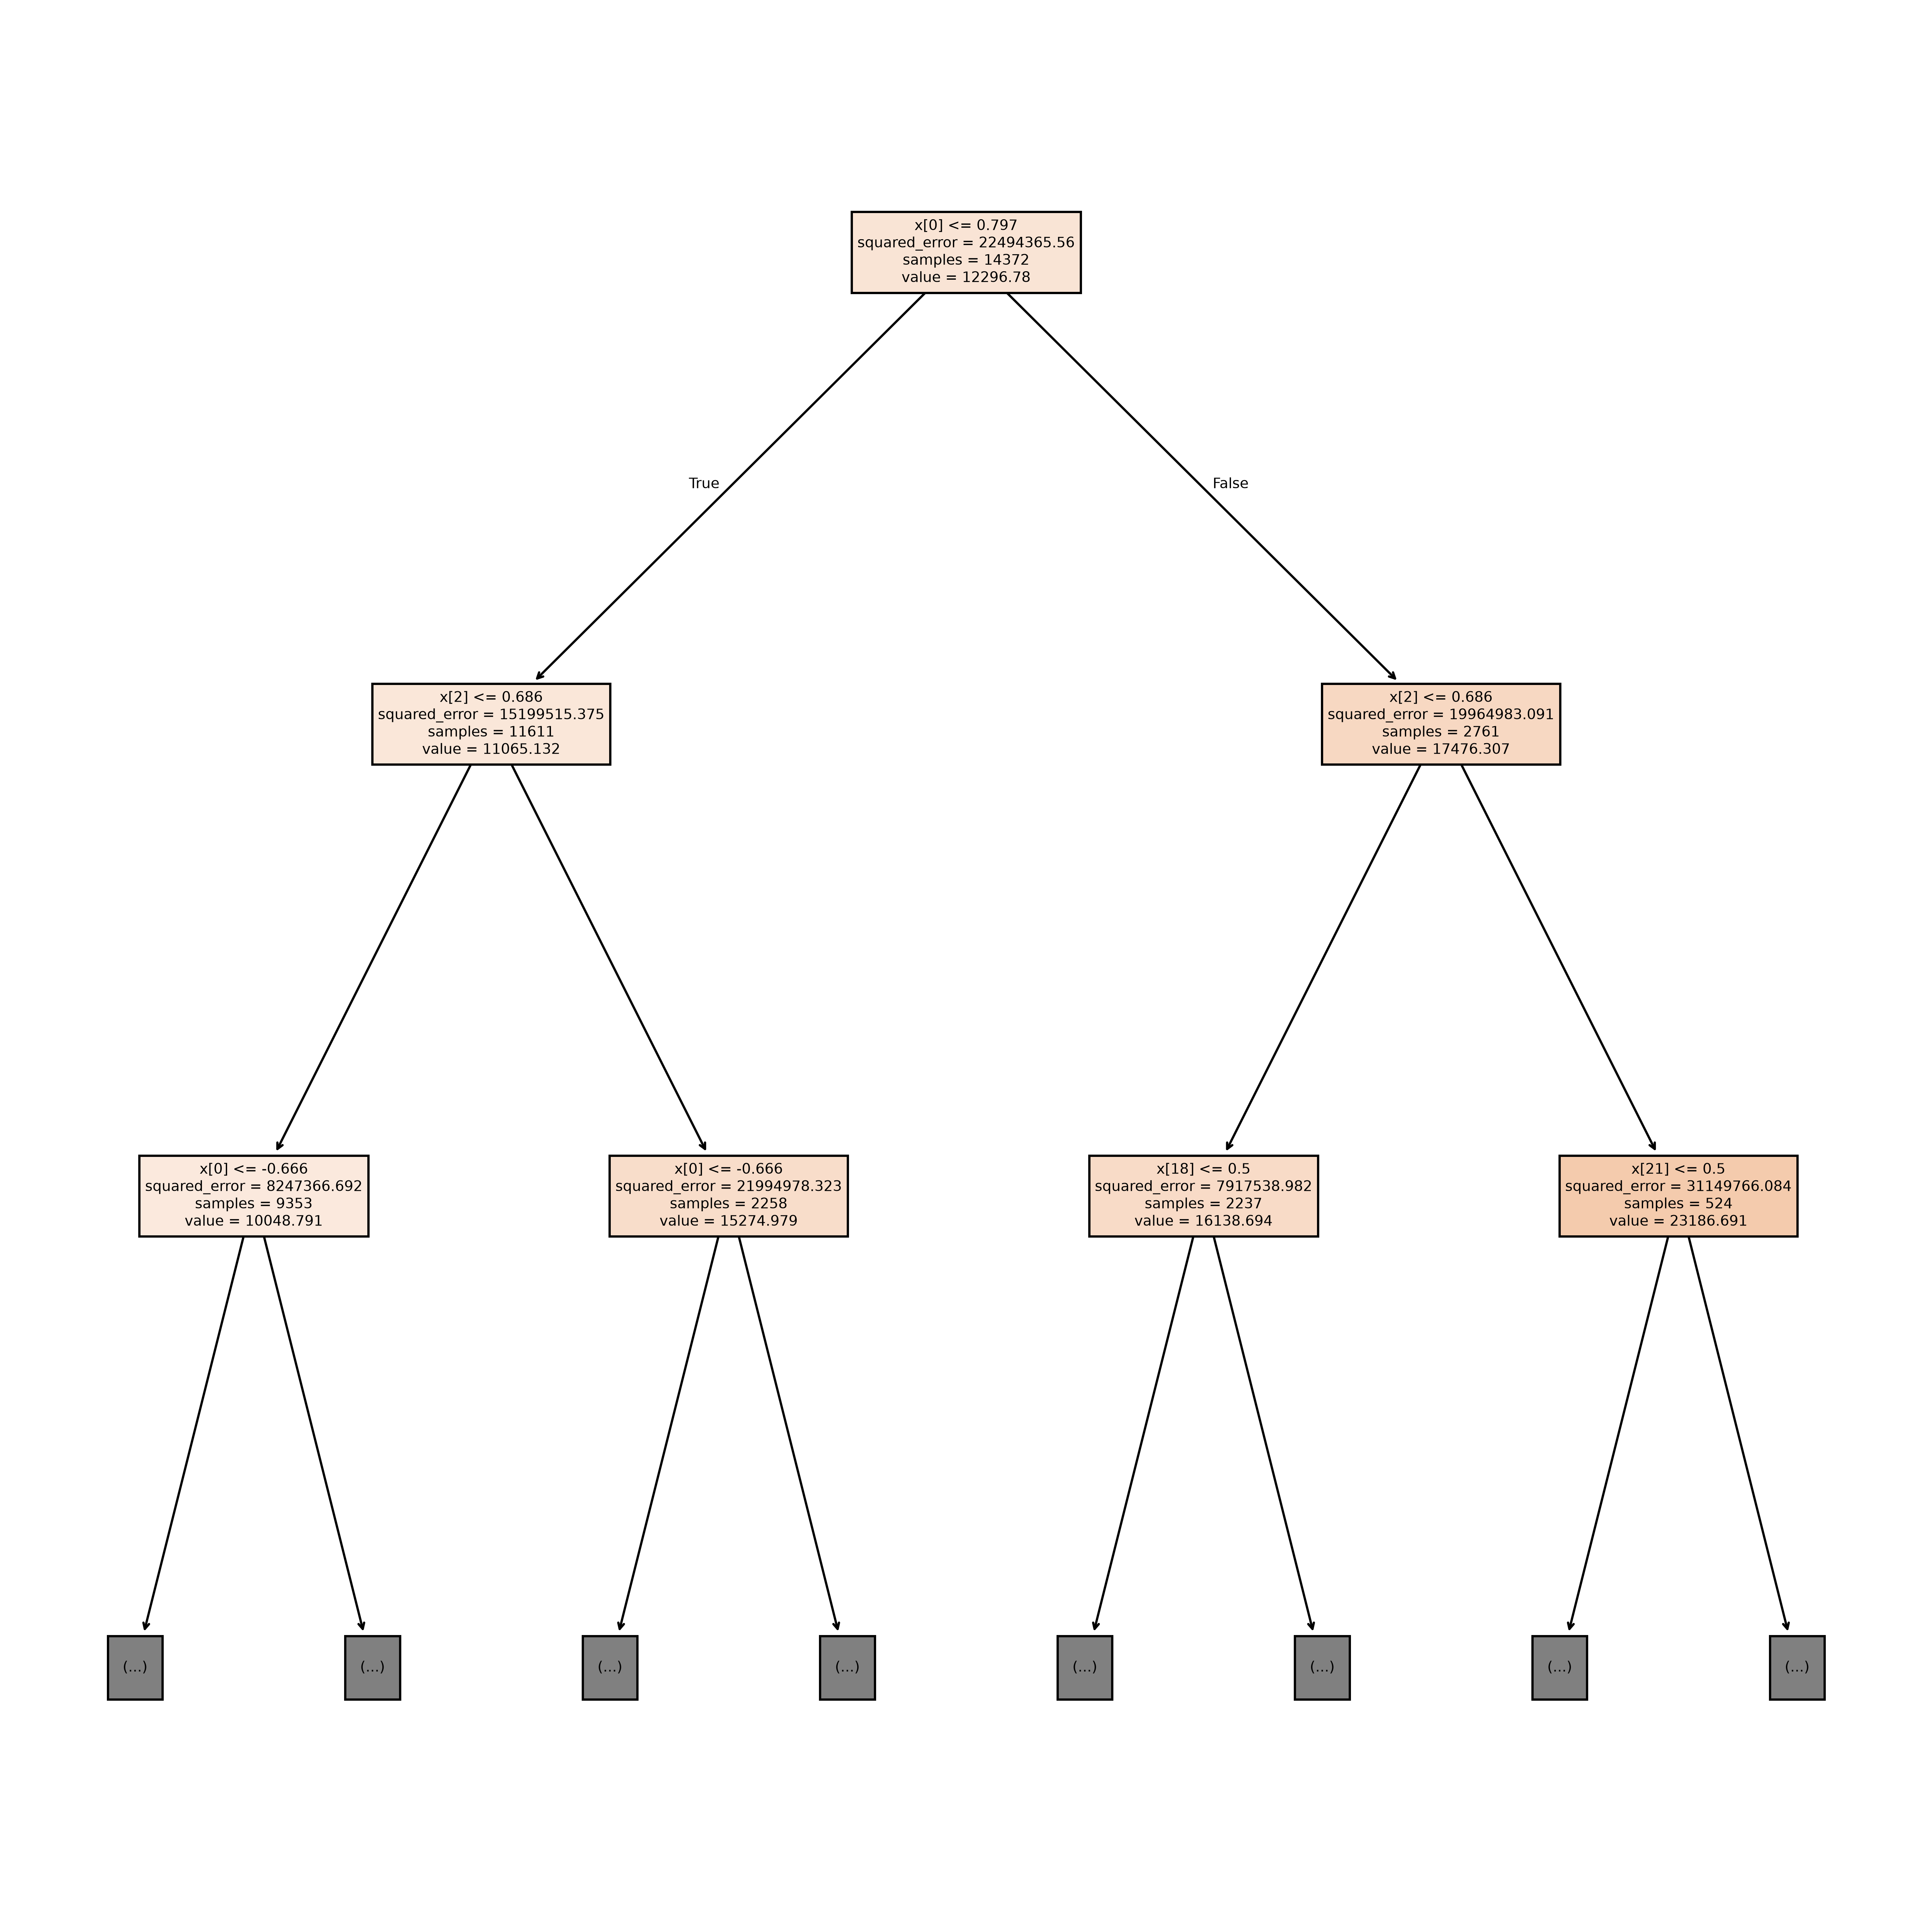

In [49]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15,15),dpi=500)
plot_tree(dec_model,filled=True,max_depth=2)
plt.show()

In [50]:
dec_y_pred=dec_model.predict(X_test)

In [51]:
from sklearn.metrics import r2_score

dec_r2=r2_score(y_test,dec_y_pred)
dec_r2


0.8872547043538358

In [52]:
n=X_test.shape[0]
p=X_test.shape[1]
dec_r2_adj=1-((1-dec_r2)*(n-1)/(n-p-1))
dec_r2_adj

0.8862415480885515

## SVM(regression)

In [53]:
from sklearn.svm import SVR

svr_model=SVR(kernel='linear')
svr_model.fit(X_train,y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [54]:
svr_y_pred=svr_model.predict(X_test)
svr_y_pred

array([ 7295.44905821, 10138.73331376,  8300.51383813, ...,
       19634.9884936 , 10451.97852412, 14699.21949144], shape=(3594,))

In [55]:
from sklearn.metrics import r2_score
svr_r2=r2_score(y_test,svr_y_pred)
svr_r2

0.7279825537891199

In [56]:
n=X_test.shape[0]
p=X_test.shape[1]
svr_r2_adj=1-((1-svr_r2)*(n-1)/(n-p-1))
svr_r2_adj

0.7255381397821701

## Visualizing Regression Model Predictions



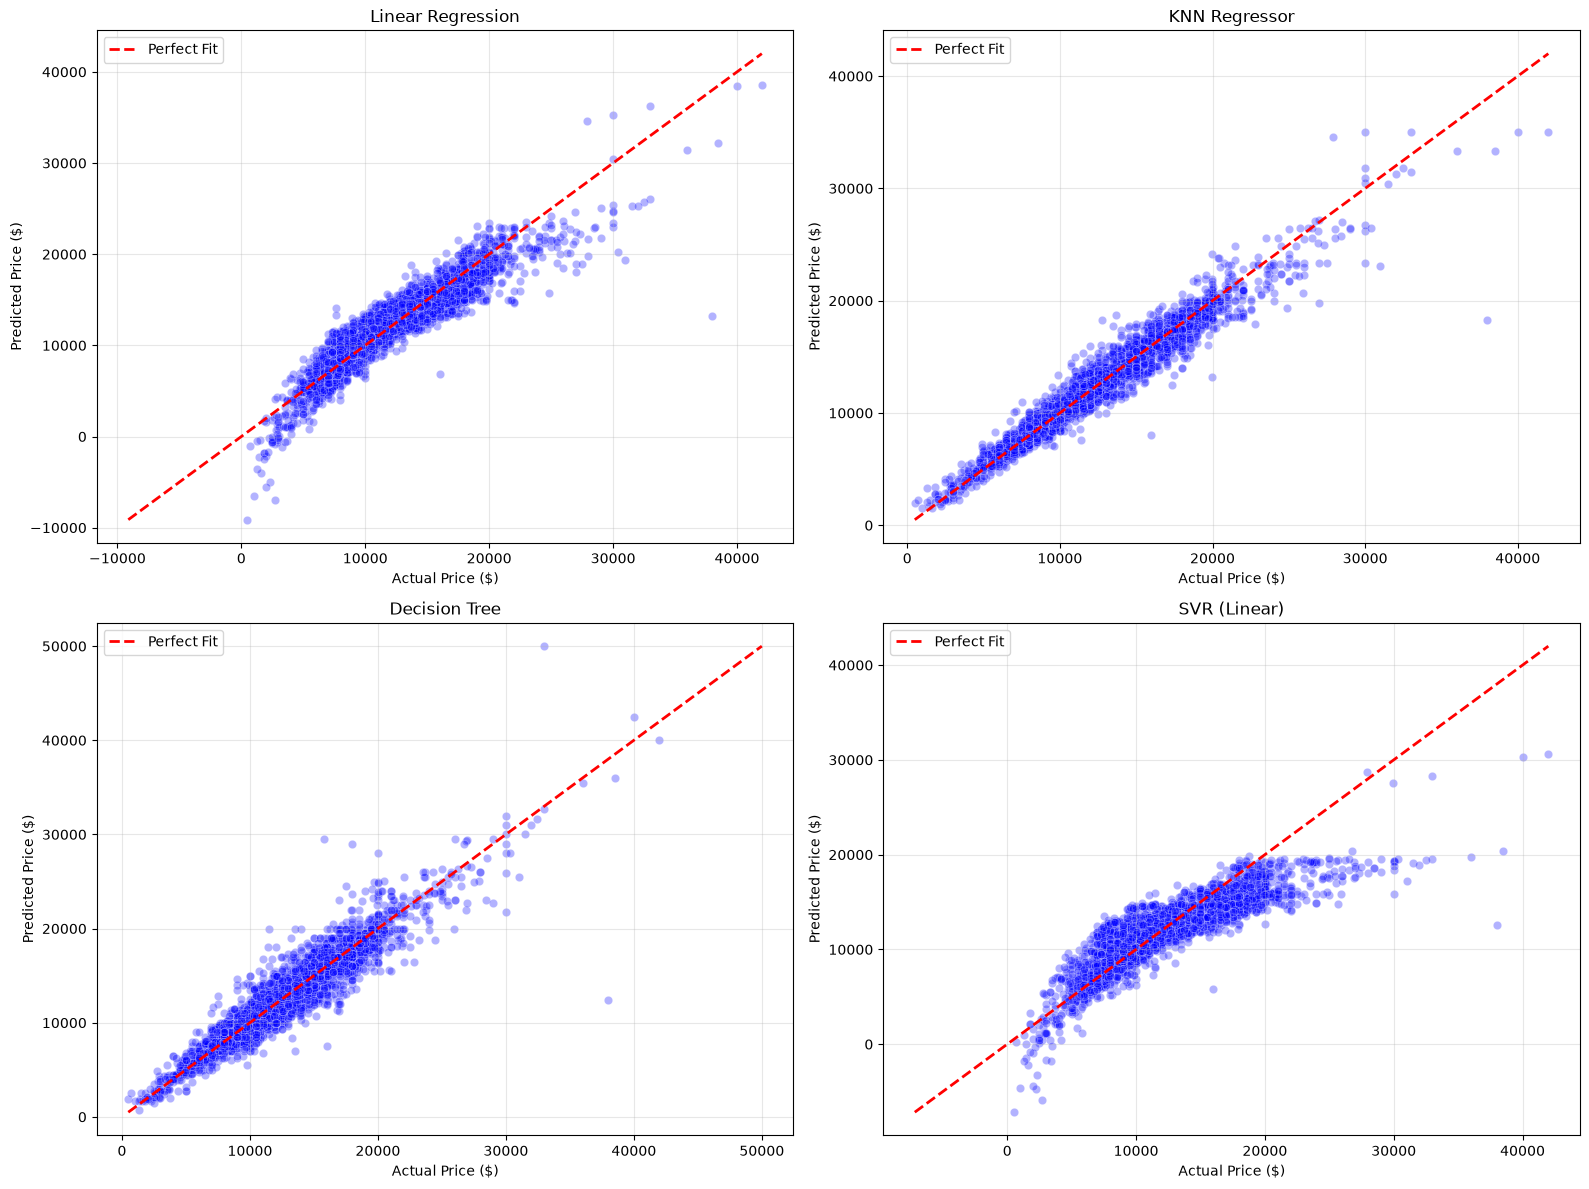

In [ ]:
def plot_actual_vs_predicted(y_true, y_pred, title, ax):
    # Scatter plot
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.3, ax=ax, color='blue')
    
    # Calculate the range for the best fit line
    max_val = max(y_true.max(), y_pred.max())
    min_val = min(y_true.min(), y_pred.min())
    
    # Plot the perfect fit line (y=x)
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label='Perfect Fit')
    
    ax.set_title(title)
    ax.set_xlabel('Actual Price ($)')
    ax.set_ylabel('Predicted Price ($)')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Create a multi-plot figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

plot_actual_vs_predicted(y_test, y_pred, 'Linear Regression', axes[0, 0])
plot_actual_vs_predicted(y_test, knn_y_pred, 'KNN Regressor', axes[0, 1])
plot_actual_vs_predicted(y_test, dec_y_pred, 'Decision Tree', axes[1, 0])
plot_actual_vs_predicted(y_test, svr_y_pred, 'SVR (Linear)', axes[1, 1])

plt.tight_layout()
plt.show()

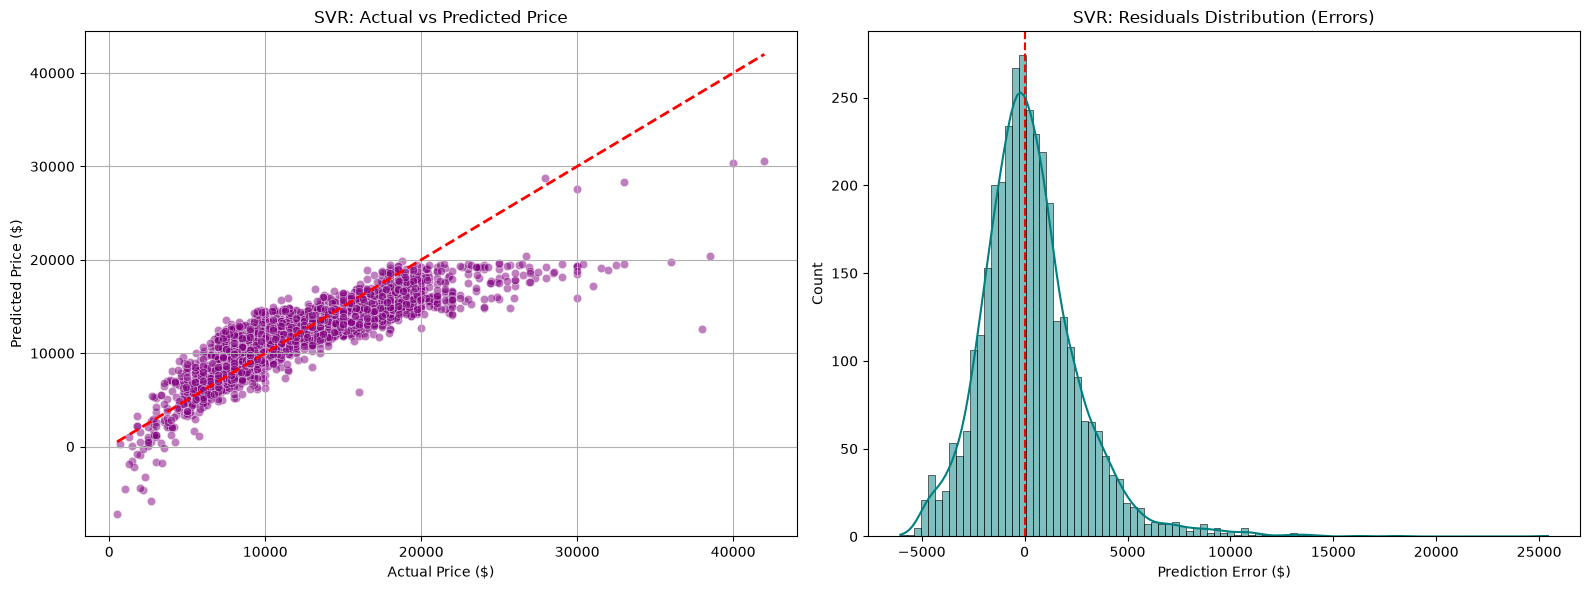

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Actual vs Predicted Scatter Plot
sns.scatterplot(x=y_test, y=svr_y_pred, alpha=0.5, ax=ax1, color='purple')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_title('SVR: Actual vs Predicted Price')
ax1.set_xlabel('Actual Price ($)')
ax1.set_ylabel('Predicted Price ($)')
ax1.grid(True)

# 2. Residual Plot (Error distribution)
residuals = y_test - svr_y_pred
sns.histplot(residuals, kde=True, ax=ax2, color='teal')
ax2.axvline(0, color='red', linestyle='--')
ax2.set_title('SVR: Residuals Distribution (Errors)')
ax2.set_xlabel('Prediction Error ($)')

plt.tight_layout()
plt.show()

## Diffrent Model Prediction Comparison

In [115]:
comparison_df = pd.DataFrame({
    'Actual Price': y_test.head(10),
    'Logistic_Predicted': logi_y_pre[:10],
    'KNN_Reg_Predicted': knn_y_pred[:10],
    'DecisionTree_Predicted': dec_y_pred[:10],
    'SVR_Predicted': svr_y_pred[:10]
})

# Calculate absolute errors for each model
comparison_df['Logistic_Error'] = np.abs(comparison_df['Actual Price'] - comparison_df['Logistic_Predicted'])
comparison_df['KNN_Reg_Error'] = np.abs(comparison_df['Actual Price'] - comparison_df['KNN_Reg_Predicted'])
comparison_df['DecisionTree_Error'] = np.abs(comparison_df['Actual Price'] - comparison_df['DecisionTree_Predicted'])
comparison_df['SVR_Error'] = np.abs(comparison_df['Actual Price'] - comparison_df['SVR_Predicted'])

display(comparison_df)

,Actual Price,Logistic_Predicted,KNN_Reg_Predicted,DecisionTree_Predicted,SVR_Predicted,Logistic_Error,KNN_Reg_Error,DecisionTree_Error,SVR_Error
17610,6995,7995,7698.4,8000.0,7295.449058,1000,703.4,1005.0,300.449058
7076,8999,11000,8640.4,10000.0,10138.733314,2001,358.6,1001.0,1139.733314
1713,7998,9000,7927.2,7998.0,8300.513838,1002,70.8,0.0,302.513838
1611,5491,6995,6330.2,5995.0,6743.255430,1504,839.2,504.0,1252.255430
16830,3790,3495,2912.2,1995.0,2306.202908,295,877.8,1795.0,1483.797092
14735,18200,17520,18415.6,18699.0,15487.990999,680,215.6,499.0,2712.009001
322,22998,19500,23289.4,22500.0,18511.162363,3498,291.4,498.0,4486.837637
8164,11000,12200,10597.0,10299.0,12796.774914,1200,403.0,701.0,1796.774914
6822,7600,11000,7854.4,7600.0,11347.814663,3400,254.4,0.0,3747.814663
2133,14985,14999,16765.8,16495.0,16477.344556,14,1780.8,1510.0,1492.344556


In [118]:

# Define the features for a real Mustang sample
mustang_data = pd.DataFrame(0, index=[0], columns=feature_cols)

# Assigning values (Example: 2019 Mustang, 5.0L Engine)
mustang_data['year'] = 2019
mustang_data['tax'] = 145
mustang_data['engineSize'] = 5.0
mustang_data['mpg'] = 20.9
mustang_data['mileage'] = 15000
mustang_data['model_ Mustang'] = 1
mustang_data['transmission_Manual'] = 1
mustang_data['fuelType_Petrol'] = 0 # Dummy is usually vs Petrol/Diesel

# Scale the numeric columns using the established scaler
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
mustang_data[num_cols] = scaler.transform(mustang_data[num_cols])

# Collect predictions
all_preds = {
    'Linear Regression': model.predict(mustang_data[feature_cols])[0],
    'Logistic Regression': logi_model.predict(mustang_data[feature_cols])[0],
    'KNN Regressor': knn_model.predict(mustang_data[feature_cols])[0],
    'Decision Tree': dec_model.predict(mustang_data[feature_cols])[0],
    'SVR (Linear)': svr_model.predict(mustang_data[feature_cols])[0]
}

# Display Results
comparison_results = pd.DataFrame({
    'Model': all_preds.keys(),
    'Predicted Price ($)': all_preds.values()
})

print("Predicted Prices for Ford Mustang:")
print("Actual price range btw 350000 to 400000")
display(comparison_results.sort_values(by='Predicted Price ($)', ascending=False))

Predicted Prices for Ford Mustang:
Actual price range btw 350000 to 400000


,Model,Predicted Price ($)
1,Logistic Regression,39998.000000
0,Linear Regression,37246.001620
3,Decision Tree,36799.000000
2,KNN Regressor,34993.200000
4,SVR (Linear),29462.731274


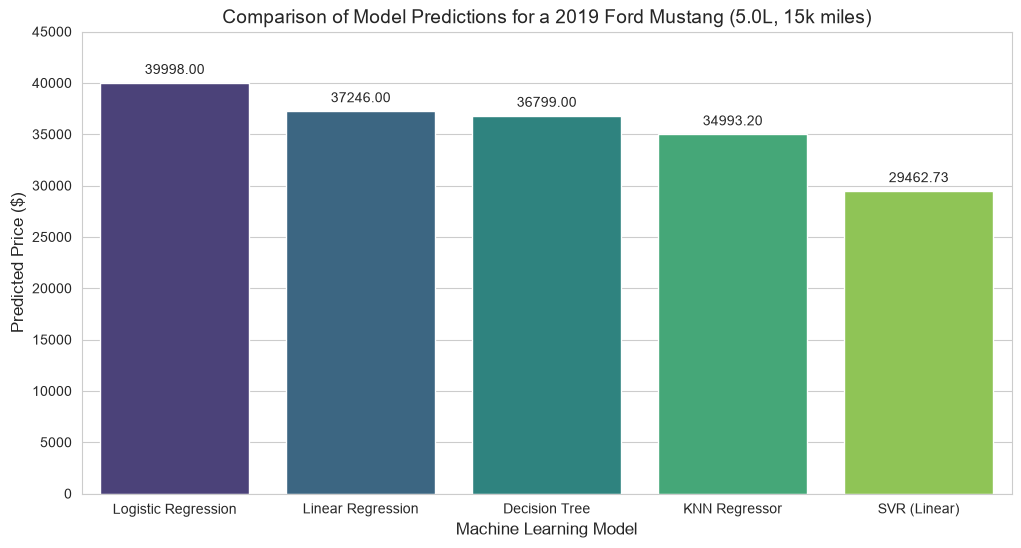

In [126]:

# Prepare data for plotting
results_sorted = comparison_results.sort_values(by='Predicted Price ($)', ascending=False)

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Create bar plot
bar_plot = sns.barplot(
    x='Model', 
    y='Predicted Price ($)', 
    data=results_sorted, 
    palette='viridis', 
    hue='Model', 
    legend=False
)

# Add labels and title
plt.title('Comparison of Model Predictions for a 2019 Ford Mustang (5.0L, 15k miles)', fontsize=14)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.xlabel('Machine Learning Model', fontsize=12)

# Add data labels on top of bars
for p in bar_plot.patches:
    bar_plot.annotate(format(p.get_height(), '.2f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.ylim(0, 45000)
plt.show()